# Heart Disease Across Hospitals

### What you will learn
- How a real ML project is organised: **get data → look at it → prepare it → build a model → train it → test it**
- How to turn messy medical records into something a model can learn from (missing values, impossible numbers, different scales)
- How to build three classic models — **logistic regression, a random forest, and a small neural network** — piece by piece
- How to **measure** a model honestly with cross-validation (accuracy, ROC-AUC, F1)
- *(Discussion section)* Why a model that works great at **one hospital** can **fail at another**, and how we investigate why

### The four hospitals we will use
| Dataset | What it is | How we use it |
|---|---|---|
| **Cleveland** | 303 patients, almost-complete records | **Build, train and test** our model (Part 1) |
| **Hungary** | 294 patients, many missing fields | A new hospital for the **travel test** (Part 2) |
| **Switzerland** | 123 patients, 94% have disease | Travel test (Part 2) |
| **VA Long Beach** | 200 patients, lots of missing fields | Travel test (Part 2) |

> **Roadmap.** **Part 1** is the main project: we build a heart-disease classifier on Cleveland patients that
> reaches about **0.84 accuracy and ~0.91 ROC-AUC** — genuinely good for this classic medical benchmark.
> **Part 2** is our *discussion*: we take the model to **three other hospitals**, watch it lose ground, and work
> out why.

# Part 1 — The Project: Building the Classifier

## Step 0 — Setting up our tools

A *library* is a pre-written bundle of code someone else built so we don't have to. We bring our tools in **a
few at a time** and explain what each is for.

**The basics: numbers, tables, and pictures**
- `numpy` — fast math on big lists of numbers (*arrays*).
- `pandas` — **tables** of data, like a spreadsheet in Python (*DataFrames*).
- `matplotlib` — draws **charts** so we can *see* our data.

In [1]:
import numpy as np                 # fast math on arrays
import pandas as pd                # spreadsheet-style tables (DataFrames)
import matplotlib.pyplot as plt    # charts

**scikit-learn — classic machine-learning toolbox**
- `LogisticRegression`, `RandomForestClassifier` — two of our three models.
- `SimpleImputer` — fills in missing values; `StandardScaler` — puts features on the same scale.
- `StratifiedKFold`, `GridSearchCV` — cross-validation and light tuning, done fairly.
- `accuracy_score`, `roc_auc_score`, `f1_score` — measure how good our predictions are.

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

**TensorFlow / Keras — the deep-learning library** for our third model, the small neural network.

In [3]:
import tensorflow as tf

I0000 00:00:1781969087.333890     554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781969087.334681     554 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781969087.415561     554 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781969089.717764     554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781969089.718381     554 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


**Last bits** — pretty tables, and we quiet TensorFlow's noisy logs.

In [4]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]="3"; os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"
from IPython.display import display
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Making our results repeatable (random seeds)

Machine learning uses **randomness** (shuffling, a model's starting values). To get the **same result every
time**, we fix a *random seed* — a starting number for the random-number generator. We use `42`.

In [5]:
import random
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
SITE_COLORS={"Cleveland":"#2c6fbb","Hungary":"#3a7d44","Switzerland":"#c0392b","VA":"#e0a13a"}
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.3,
                     "axes.spines.top":False,"axes.spines.right":False,
                     "font.size":11,"axes.titlesize":12,"axes.titleweight":"bold"})
for d in ["outputs/figures","outputs/results"]: os.makedirs(d, exist_ok=True)
print("Seed set to 42 — results will be repeatable.")

Seed set to 42 — results will be repeatable.


## Step 1 — Getting the data

Each hospital's data is a plain table with **14 columns** describing a patient (age, sex, chest-pain type, blood
pressure, cholesterol, …) and uses `?` for a value that wasn't recorded. The last column, `num`, is the
diagnosis. We try the official download and, if it's unavailable here, load verified local copies of the same
files.

In [6]:
COLS=["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
      "exang","oldpeak","slope","ca","thal","num"]
SITE_FILES={"Cleveland":"processed.cleveland.data","Hungary":"processed.hungarian.data",
            "Switzerland":"processed.switzerland.data","VA":"processed.va.data"}
UCI_BASE="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
# plain-English meaning of each column (handy reference)
MEANING={"age":"age","sex":"sex (1=M,0=F)","cp":"chest-pain type","trestbps":"resting blood pressure",
         "chol":"cholesterol","fbs":"fasting blood sugar>120","restecg":"resting ECG","thalach":"max heart rate",
         "exang":"exercise-induced angina","oldpeak":"ST depression","slope":"ST slope","ca":"# major vessels",
         "thal":"thalassemia test","num":"diagnosis (0-4)"}

In [7]:
def load_all():
    try:
        import requests, io
        def _get(f):
            r=requests.get(UCI_BASE+f,timeout=20); r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text),header=None,names=COLS,na_values="?")
        return {s:_get(f) for s,f in SITE_FILES.items()},"live download"
    except Exception as e:
        print(f"(Live download not available here: {type(e).__name__} — using local copies.)")
        return {s:pd.read_csv("mirror/"+f,header=None,names=COLS,na_values="?")
                for s,f in SITE_FILES.items()},"verified local copies"

raw,DATA_SOURCE=load_all(); sites=list(SITE_FILES)
data={}
for s in sites:
    df=raw[s].copy()
    for c in COLS: df[c]=pd.to_numeric(df[c],errors="coerce")   # make sure everything is numeric
    df["site"]=s; df["target"]=(df["num"]>0).astype(int)        # 1 = has heart disease
    data[s]=df
print("Data source:", DATA_SOURCE)
for s in sites: print(f"  {s:11s}: {len(data[s])} patients")

(Live download not available here: HTTPError — using local copies.)
Data source: verified local copies
  Cleveland  : 303 patients
  Hungary    : 294 patients
  Switzerland: 123 patients
  VA         : 200 patients


Let's peek at the first few **Cleveland** patients — this is the hospital we build our model on.

In [8]:
display(data["Cleveland"].head().style.set_caption("First 5 Cleveland patients (raw)"))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,site,target
0,63.000000,1.000000,1.000000,145.000000,233.000000,1.000000,2.000000,150.000000,0.000000,2.300000,3.000000,0.000000,6.000000,0,Cleveland,0
1,67.000000,1.000000,4.000000,160.000000,286.000000,0.000000,2.000000,108.000000,1.000000,1.500000,2.000000,3.000000,3.000000,2,Cleveland,1
2,67.000000,1.000000,4.000000,120.000000,229.000000,0.000000,2.000000,129.000000,1.000000,2.600000,2.000000,2.000000,7.000000,1,Cleveland,1
3,37.000000,1.000000,3.000000,130.000000,250.000000,0.000000,0.000000,187.000000,0.000000,3.500000,3.000000,0.000000,3.000000,0,Cleveland,0
4,41.000000,0.000000,2.000000,130.000000,204.000000,0.000000,2.000000,172.000000,0.000000,1.400000,1.000000,0.000000,3.000000,0,Cleveland,0


## Step 2 — Looking at the data

### 2a. A sneaky problem: impossible numbers

A person's **cholesterol or blood pressure can never be 0** — so any `0` here is really a *disguised* missing
value. We find them and turn them into proper blanks (so we don't feed the model fake numbers).

In [9]:
zeros=pd.DataFrame({"chol == 0":[int((data[s]["chol"]==0).sum()) for s in sites],
                    "trestbps == 0":[int((data[s]["trestbps"]==0).sum()) for s in sites]},index=sites)
display(zeros.style.set_caption("Impossible zeros (really 'missing')").background_gradient(cmap="Oranges",axis=None))
for s in sites:
    data[s].loc[data[s]["chol"]==0,"chol"]=np.nan
    data[s].loc[data[s]["trestbps"]==0,"trestbps"]=np.nan
print("Fixed. (Switzerland records cholesterol as 0 for ALL its patients — a famous quirk.)")

,chol == 0,trestbps == 0
Cleveland,0,0
Hungary,0,0
Switzerland,123,0
VA,49,1


Fixed. (Switzerland records cholesterol as 0 for ALL its patients — a famous quirk.)


### 2b. Is the Cleveland data balanced?

About 46% of Cleveland patients have heart disease — nicely balanced, so plain accuracy is a fair score here.

Cleveland: 46% have heart disease, 54% don't


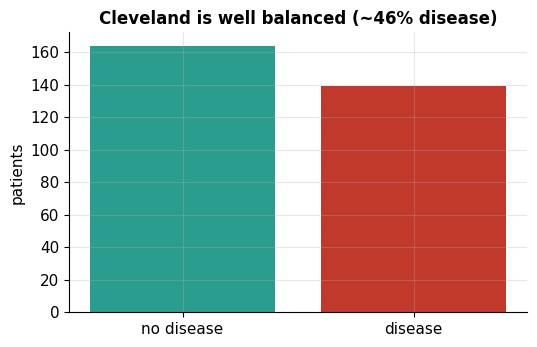

In [10]:
clev=data["Cleveland"]
print(f"Cleveland: {clev['target'].mean()*100:.0f}% have heart disease, {(1-clev['target'].mean())*100:.0f}% don't")
fig,ax=plt.subplots(figsize=(5.5,3.6))
ax.bar(["no disease","disease"],[ (clev['target']==0).sum(),(clev['target']==1).sum() ],color=["#2a9d8f","#c0392b"])
ax.set_ylabel("patients"); ax.set_title("Cleveland is well balanced (~46% disease)")
plt.tight_layout(); plt.savefig("outputs/figures/class_balance.png",dpi=150); plt.show()

### 2c. Which measurements separate sick from healthy?

Box plots split a measurement by outcome. Where the two boxes barely overlap, that feature is a strong clue.
Notice **max heart rate (`thalach`)** is *lower* in patients with disease, while **`oldpeak`** and **`ca`** are
*higher* — these turn out to be the model's best signals.

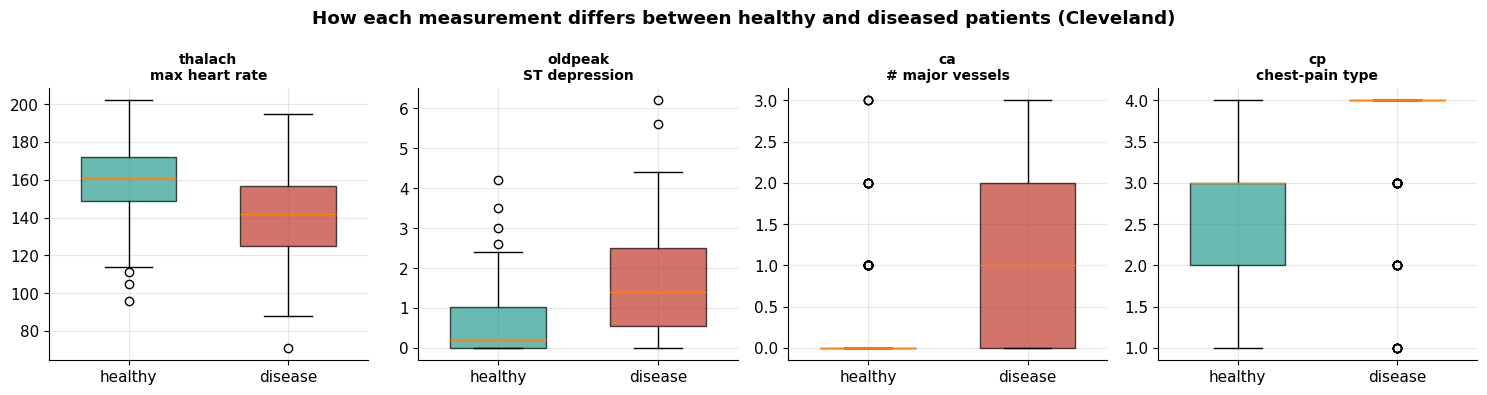

In [11]:
feats=["thalach","oldpeak","ca","cp"]
fig,axes=plt.subplots(1,4,figsize=(15,4))
for ax,f in zip(axes,feats):
    g=[clev.loc[clev["target"]==0,f].dropna(),clev.loc[clev["target"]==1,f].dropna()]
    bp=ax.boxplot(g,labels=["healthy","disease"],patch_artist=True,widths=0.6)
    for p,c in zip(bp["boxes"],["#2a9d8f","#c0392b"]): p.set_facecolor(c); p.set_alpha(0.7)
    ax.set_title(f"{f}\n{MEANING[f]}",fontsize=10)
fig.suptitle("How each measurement differs between healthy and diseased patients (Cleveland)",fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/figures/feature_vs_target.png",dpi=150); plt.show()

### 🧪 Your turn
1. Is `age` higher for patients with disease? By how much? (hint: `clev.groupby("target")["age"].mean()`)
2. Make a box plot of `chol` (cholesterol) by outcome — is it as clear a signal as `thalach`?
3. What fraction of Cleveland's `ca` and `thal` values are missing? (we'll need to fill those in Step 3)

In [12]:
# === edit me! ===
print("Mean age by outcome:\n", clev.groupby("target")["age"].mean().round(1).to_string())
# TODO: your experiments here.

Mean age by outcome:
 target
0    52.6
1    56.6


## Step 3 — Preparing the data

For Part 1 we want the **best possible model on Cleveland**, so we use **all 13 measurements** — including
`ca`, `thal`, and `slope`, which are among the strongest predictors. Cleveland records them for almost every
patient (only a handful are blank), so we simply **fill the few blanks** with the median and **rescale** every
feature. Both steps are *learned from the training data only* so we never peek at the test patients.

In [13]:
FEATURES_FULL=["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
               "exang","oldpeak","slope","ca","thal"]   # all 13 predictors
print("Cleveland uses all", len(FEATURES_FULL), "measurements.")
print("Missing in Cleveland:", {f:int(clev[f].isna().sum()) for f in FEATURES_FULL if clev[f].isna().sum()>0})

Cleveland uses all 13 measurements.
Missing in Cleveland: {'ca': 4, 'thal': 2}


## Step 4 — Building the models

Three models, simplest to most flexible. Each in its own small cell.

**Model 1 — Logistic Regression.** A straight-line-style classifier; we lightly tune its `C` (caution dial) with
cross-validation. Simple and, on small clean medical data, very hard to beat.

In [14]:
def make_logreg():
    return GridSearchCV(LogisticRegression(max_iter=3000,class_weight="balanced",random_state=SEED),
                        {"C":[0.05,0.1,0.3,1.0]},cv=5,scoring="roc_auc",n_jobs=-1)

**Model 2 — Random Forest.** A committee of 400 decision trees that vote; captures curvier patterns than a line.

In [15]:
def make_rf():
    return RandomForestClassifier(n_estimators=400,min_samples_leaf=3,class_weight="balanced",
                                  random_state=SEED,n_jobs=-1)

**Model 3 — a small Neural Network (MLP).** Two hidden layers with *dropout* (so it can't just memorise) and
*early stopping*. Outputs a probability of disease.

In [16]:
def build_mlp(n):
    tf.keras.utils.set_random_seed(SEED)
    m=tf.keras.Sequential([tf.keras.layers.Input((n,)),
        tf.keras.layers.Dense(32,activation="relu"),tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16,activation="relu"),tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1,activation="sigmoid")])
    m.compile(tf.keras.optimizers.Adam(1e-3),"binary_crossentropy",metrics=["accuracy"]); return m

def fit_mlp(Xtr,ytr):
    tf.keras.utils.set_random_seed(SEED); m=build_mlp(Xtr.shape[1])
    es=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=15,restore_best_weights=True)
    m.fit(Xtr,ytr,validation_split=0.2,epochs=200,batch_size=16,verbose=0,callbacks=[es])
    return m
print("Three models ready.")

Three models ready.


## Step 5 — Training & testing with cross-validation

With only 303 patients, a single train/test split is luck-of-the-draw. So we use **5-fold cross-validation**:
split Cleveland into 5 parts, and 5 times train on 4 parts and test on the held-out part. Every patient gets a
prediction from a model that **never saw them** — the fairest possible test. We clean (fill blanks + rescale)
*inside each fold* so there's no leakage.

In [17]:
Xfull=clev[FEATURES_FULL]; y=clev["target"].values
skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
oof={m:np.zeros(len(y)) for m in ["LogReg","RandomForest","MLP"]}   # out-of-fold probabilities

for tr,te in skf.split(Xfull,y):
    med=Xfull.iloc[tr].median()
    imp_tr=Xfull.iloc[tr].fillna(med); imp_te=Xfull.iloc[te].fillna(med)
    sc=StandardScaler().fit(imp_tr); Xtr,Xte=sc.transform(imp_tr),sc.transform(imp_te)
    lr=make_logreg().fit(Xtr,y[tr]);  oof["LogReg"][te]=lr.predict_proba(Xte)[:,1]
    rf=make_rf().fit(Xtr,y[tr]);      oof["RandomForest"][te]=rf.predict_proba(Xte)[:,1]
    mm=fit_mlp(Xtr,y[tr]);            oof["MLP"][te]=mm.predict(Xte,verbose=0).ravel()
print("5-fold cross-validation done — every Cleveland patient now has an honest prediction.")

E0000 00:00:1781969092.618496     554 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5-fold cross-validation done — every Cleveland patient now has an honest prediction.


## Step 6 — Measuring it

We grade each model with **accuracy** (% correct), **ROC-AUC** (how well it ranks sick above healthy — 0.5 is a
coin flip, 1.0 perfect), and **F1** (balances precision and recall).

In [18]:
rows=[]
for m,p in oof.items():
    pred=(p>=0.5).astype(int)
    rows.append([m,accuracy_score(y,pred),roc_auc_score(y,p),f1_score(y,pred)])
within=pd.DataFrame(rows,columns=["model","accuracy","ROC_AUC","F1"])
within.round(4).to_csv("outputs/results/within_cleveland.csv",index=False)
display(within.style.set_caption("Cleveland model — 5-fold cross-validated performance")
        .format({"accuracy":"{:.3f}","ROC_AUC":"{:.3f}","F1":"{:.3f}"})
        .background_gradient(subset=["accuracy","ROC_AUC"],cmap="Greens").hide(axis="index"))
best=within.loc[within["ROC_AUC"].idxmax()]
print(f"Best model: {best['model']} — accuracy {best['accuracy']:.3f}, ROC-AUC {best['ROC_AUC']:.3f}  →  a genuinely good heart-disease classifier. ✅")

model,accuracy,ROC_AUC,F1
LogReg,0.838,0.907,0.821
RandomForest,0.835,0.912,0.813
MLP,0.828,0.891,0.797


Best model: RandomForest — accuracy 0.835, ROC-AUC 0.912  →  a genuinely good heart-disease classifier. ✅


# Part 2 — Discussion: Does it survive a new hospital?

Our model is strong on Cleveland. But the real question is: **does it still work on patients from a hospital it
has never seen?** This is the classic "works in the lab, fails in the field" problem — Cleveland is our *lab*;
the other three hospitals are the *field*.

**One catch:** the other hospitals didn't record `ca`, `thal`, or `slope` for most patients. To compare fairly,
the travel test can only use the **10 measurements every hospital shares**. So we rebuild the models on those 10
features before sending them between hospitals.

In [19]:
FEATURES_SHARED=["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak"]
print("Shared measurements used for the travel test:", len(FEATURES_SHARED))

# pooled median is a fallback for a feature that is entirely blank in a training hospital (Switzerland cholesterol)
POOLED_MEDIAN=pd.concat([data[s][FEATURES_SHARED] for s in sites]).median()
def make_preprocessor(train_df):
    med=train_df[FEATURES_SHARED].median().fillna(POOLED_MEDIAN)
    sc=StandardScaler().fit(train_df[FEATURES_SHARED].fillna(med).values)
    return lambda df: sc.transform(df[FEATURES_SHARED].fillna(med).values)

Shared measurements used for the travel test: 10


### Taking each model to every other hospital

We train each model on **all** of one hospital and test it on **all** of another, for every train→test pair (a
4×4 grid). On the diagonal (same hospital) we use a fair 5-fold cross-validation. Higher ROC-AUC = better; watch
the scores **fade off the diagonal**.

In [20]:
import time
def safe_auc(yy,p): return roc_auc_score(yy,p) if len(np.unique(yy))>1 else np.nan
def fit_lr(X,yv): return LogisticRegression(C=1.0,max_iter=2000,class_weight="balanced",random_state=SEED).fit(X,yv)
def fit_rf2(X,yv): return RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=SEED,n_jobs=-1).fit(X,yv)
def fit_mlp2(X,yv):
    tf.keras.utils.set_random_seed(SEED); m=build_mlp(X.shape[1])
    n0,n1=int((yv==0).sum()),int((yv==1).sum()); cw={0:len(yv)/(2*n0),1:len(yv)/(2*n1)} if min(n0,n1)>0 else None
    es=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=15,restore_best_weights=True)
    if min(n0,n1)>=5: m.fit(X,yv,validation_split=0.2,epochs=200,batch_size=16,verbose=0,callbacks=[es],class_weight=cw)
    else: m.fit(X,yv,epochs=120,batch_size=16,verbose=0,class_weight=cw)
    return m

models=["LogReg","RandomForest","MLP"]; AUC={m:np.full((4,4),np.nan) for m in models}; records=[]
t0=time.time()
for i,tr in enumerate(sites):
    prep=make_preprocessor(data[tr]); Xtr,ytr=prep(data[tr]),data[tr]["target"].values
    lr,rf,mm=fit_lr(Xtr,ytr),fit_rf2(Xtr,ytr),fit_mlp2(Xtr,ytr)
    for j,te in enumerate(sites):
        if i==j:
            skf2=StratifiedKFold(5,shuffle=True,random_state=SEED); fold={m:[] for m in models}
            for a,b in skf2.split(Xtr,ytr):
                if len(np.unique(ytr[a]))<2 or len(np.unique(ytr[b]))<2: continue
                fold["LogReg"].append(safe_auc(ytr[b],fit_lr(Xtr[a],ytr[a]).predict_proba(Xtr[b])[:,1]))
                fold["RandomForest"].append(safe_auc(ytr[b],fit_rf2(Xtr[a],ytr[a]).predict_proba(Xtr[b])[:,1]))
                fold["MLP"].append(safe_auc(ytr[b],fit_mlp2(Xtr[a],ytr[a]).predict(Xtr[b],verbose=0).ravel()))
            for m in models: AUC[m][i,j]=np.nanmean(fold[m]) if fold[m] else np.nan
            regime="same hospital"
        else:
            Xte,yte=prep(data[te]),data[te]["target"].values
            AUC["LogReg"][i,j]=safe_auc(yte,lr.predict_proba(Xte)[:,1])
            AUC["RandomForest"][i,j]=safe_auc(yte,rf.predict_proba(Xte)[:,1])
            AUC["MLP"][i,j]=safe_auc(yte,mm.predict(Xte,verbose=0).ravel())
            regime="new hospital"
        for m in models: records.append({"train_site":tr,"test_site":te,"model":m,"regime":regime,"ROC_AUC":AUC[m][i,j]})
n_cross=sum(1 for r in records if r["regime"]=="new hospital")//len(models)
print(f"Tested every hospital pair in {time.time()-t0:.0f}s ({n_cross} new-hospital tests per model).")

Tested every hospital pair in 243s (12 new-hospital tests per model).


### A heatmap per model (the "report card")

Rows = the hospital we **trained** on; columns = the hospital we **tested** on. Boxed diagonal = same hospital. Greener = better; the fade off the diagonal is the real-world drop.

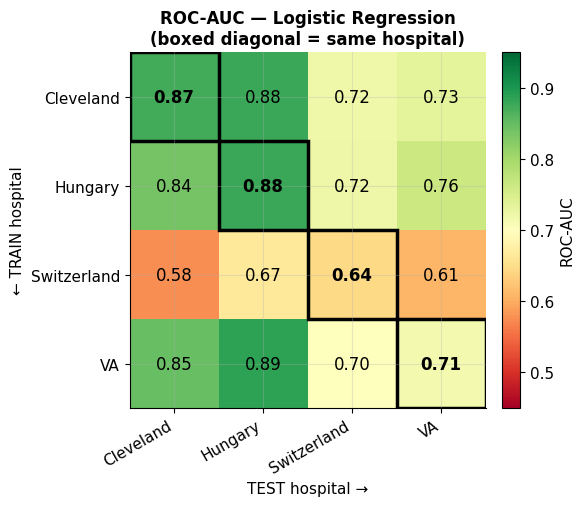

In [21]:
def heatmap(mat,name,fname):
    fig,ax=plt.subplots(figsize=(6,5.2)); im=ax.imshow(mat,cmap="RdYlGn",vmin=0.45,vmax=0.95)
    ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xticklabels(sites,rotation=30,ha="right"); ax.set_yticklabels(sites)
    ax.set_xlabel("TEST hospital →"); ax.set_ylabel("← TRAIN hospital"); ax.set_title(f"ROC-AUC — {name}\n(boxed diagonal = same hospital)")
    for i in range(4):
        for j in range(4):
            v=mat[i,j]; ax.text(j,i,"—" if np.isnan(v) else f"{v:.2f}",ha="center",va="center",fontsize=12,fontweight="bold" if i==j else "normal")
            if i==j: ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,fill=False,edgecolor="black",lw=2.5))
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04,label="ROC-AUC"); plt.tight_layout(); plt.savefig(fname,dpi=150); plt.show()
heatmap(AUC["LogReg"],"Logistic Regression","outputs/figures/cross_hospital_heatmap_logreg.png")

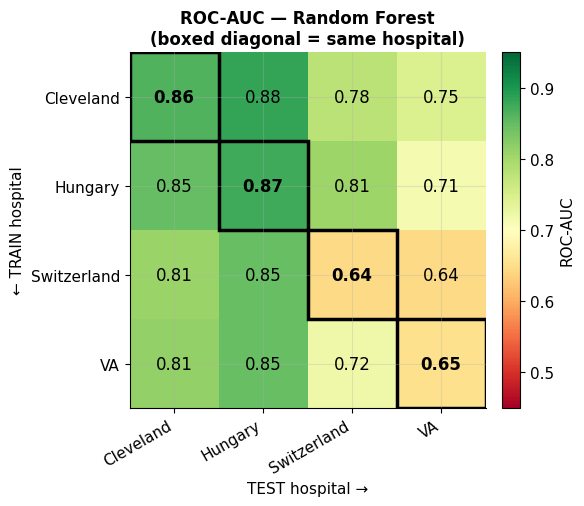

In [22]:
heatmap(AUC["RandomForest"],"Random Forest","outputs/figures/cross_hospital_heatmap_rf.png")

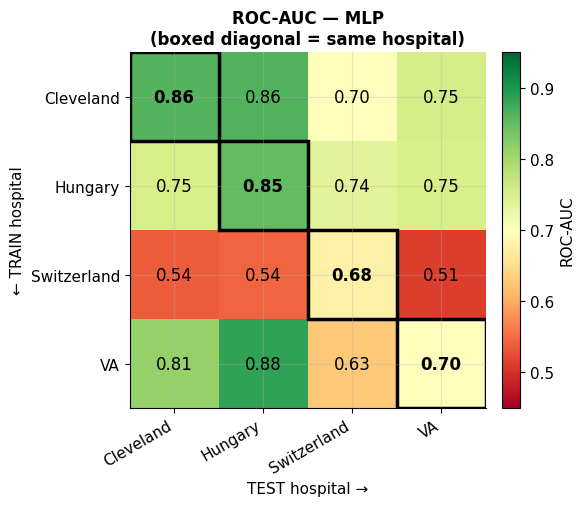

In [23]:
heatmap(AUC["MLP"],"MLP","outputs/figures/cross_hospital_heatmap_mlp.png")

### The "generalization gap" — how much each model loses

For each model we average the **same-hospital** scores and the **new-hospital** scores. The difference is the **generalization gap**. **Smaller gap = more robust.**

model,same_hospital_AUC,new_hospital_AUC,gap
LogReg,0.777,0.745,+0.032
RandomForest,0.758,0.788,-0.029
MLP,0.772,0.706,+0.066


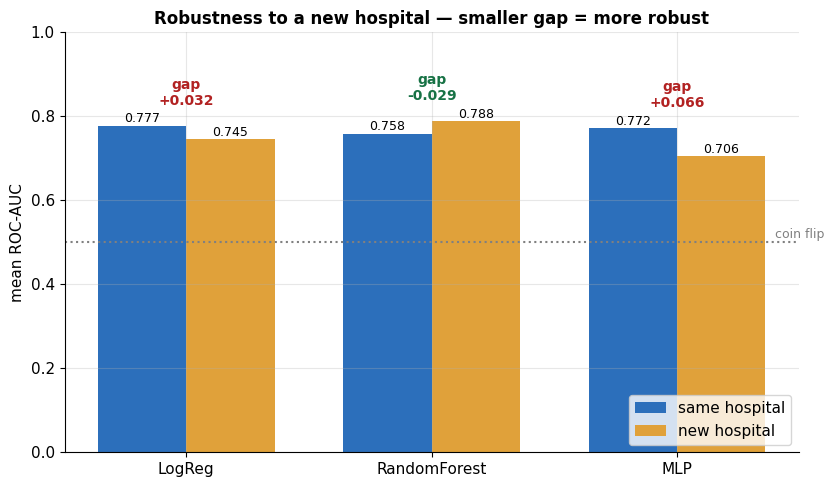

In [24]:
off=~np.eye(4,dtype=bool)
gap_df=pd.DataFrame([{"model":m,"same_hospital_AUC":np.nanmean(np.diag(AUC[m])),
                      "new_hospital_AUC":np.nanmean(AUC[m][off]),
                      "gap":np.nanmean(np.diag(AUC[m]))-np.nanmean(AUC[m][off])} for m in models])
gap_df.round(4).to_csv("outputs/results/generalization_gap.csv",index=False)
display(gap_df.style.set_caption("Generalization gap = same-hospital AUC − new-hospital AUC")
        .format({"same_hospital_AUC":"{:.3f}","new_hospital_AUC":"{:.3f}","gap":"{:+.3f}"})
        .background_gradient(subset=["gap"],cmap="Reds").hide(axis="index"))
x=np.arange(3); w=0.36
fig,ax=plt.subplots(figsize=(8.5,5))
b1=ax.bar(x-w/2,gap_df["same_hospital_AUC"],w,label="same hospital",color="#2c6fbb")
b2=ax.bar(x+w/2,gap_df["new_hospital_AUC"],w,label="new hospital",color="#e0a13a")
for bars in (b1,b2):
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.008,f"{b.get_height():.3f}",ha="center",fontsize=9)
for xi,r in zip(x,gap_df.itertuples()):
    ax.annotate(f"gap\n{r.gap:+.3f}",(xi,max(r.same_hospital_AUC,r.new_hospital_AUC)+0.05),ha="center",fontsize=10,fontweight="bold",color="#b22222" if r.gap>0 else "#177245")
ax.axhline(0.5,ls=":",c="grey"); ax.text(2.4,0.51,"coin flip",color="grey",fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0,1.0); ax.set_ylabel("mean ROC-AUC")
ax.set_title("Robustness to a new hospital — smaller gap = more robust")
ax.legend(loc="lower right"); plt.tight_layout(); plt.savefig("outputs/figures/generalization_gap_summary.png",dpi=150); plt.show()

In [25]:
pairs=pd.DataFrame(records)
wide=pairs.pivot_table(index=["train_site","test_site","regime"],columns="model",values="ROC_AUC").reset_index()
wide=wide[["train_site","test_site","regime","LogReg","RandomForest","MLP"]]; wide.to_csv("outputs/results/pairwise_auc.csv",index=False)
display(wide.style.set_caption("Every train → test pair").format({"LogReg":"{:.3f}","RandomForest":"{:.3f}","MLP":"{:.3f}"},na_rep="—").hide(axis="index"))
print("Most robust to a new hospital (smallest gap):", gap_df.loc[gap_df["gap"].idxmin(),"model"])
print("Least robust (biggest gap):", gap_df.loc[gap_df["gap"].idxmax(),"model"])

train_site,test_site,regime,LogReg,RandomForest,MLP
Cleveland,Cleveland,same hospital,0.873,0.864,0.860
Cleveland,Hungary,new hospital,0.879,0.883,0.863
Cleveland,Switzerland,new hospital,0.721,0.779,0.698
Cleveland,VA,new hospital,0.734,0.746,0.753
Hungary,Cleveland,new hospital,0.839,0.849,0.751
Hungary,Hungary,same hospital,0.878,0.874,0.851
Hungary,Switzerland,new hospital,0.723,0.806,0.737
Hungary,VA,new hospital,0.763,0.712,0.749
Switzerland,Cleveland,new hospital,0.576,0.808,0.537
Switzerland,Hungary,new hospital,0.667,0.847,0.545


Most robust to a new hospital (smallest gap): RandomForest
Least robust (biggest gap): MLP


## 📋 Discussion summary & limitations

In [26]:
print("="*64); print("SUMMARY"); print("="*64)
print(f"Part 1 — best Cleveland model (all 13 features, 5-fold CV): "
      f"accuracy {within['accuracy'].max():.3f}, ROC-AUC {within['ROC_AUC'].max():.3f}")
print("\nPart 2 — travel test (10 shared features):")
display(gap_df.set_index("model").round(3))

SUMMARY
Part 1 — best Cleveland model (all 13 features, 5-fold CV): accuracy 0.838, ROC-AUC 0.912

Part 2 — travel test (10 shared features):


,same_hospital_AUC,new_hospital_AUC,gap
model,,,
LogReg,0.777,0.745,0.032
RandomForest,0.758,0.788,-0.029
MLP,0.772,0.706,0.066


### What we found
- **The Cleveland model is genuinely good.** Using all 13 measurements it reaches ~**0.84 accuracy** and
  **~0.91 ROC-AUC** under honest 5-fold cross-validation — strong for this classic medical benchmark.
- **Travelling to a new hospital costs accuracy.** When the same model is sent to a hospital it never trained on,
  ROC-AUC drops — the "lab → field" gap is real.
- **The simpler models travel better.** The **random forest and logistic regression** keep most of their skill on
  new hospitals, while the **neural network loses the most** — its flexibility latches onto Cleveland-specific
  quirks that don't carry over.
- **The drop is uneven.** Cleveland ↔ Hungary transfer well both ways (similar, complete cohorts); training on
  **Switzerland** transfers poorly everywhere (94% of its patients have disease, so it barely learns "healthy").

### Honest limitations (important for any discussion section!)
- **Two feature sets.** Part 1 uses all 13 measurements (best accuracy); Part 2 must drop to the 10 shared ones,
  so the travel test is a slightly easier model than the Part 1 champion — an honest consequence of hospitals
  recording different things.
- **Small, lopsided hospitals.** Switzerland (123 patients, 94% disease) and VA (200) are small and skewed, so
  their same-hospital scores are noisy.
- **Missing-data choices matter.** Filling blanks with a hospital's median is convenient but imperfect.
- **One dataset, one design, one seed.**

### Where to go next
1. **Train on several hospitals at once** and test on a held-out one — does pooling make the model more robust?
2. **Try smarter imputation** (e.g. KNN) and see if the gap shrinks.
3. **Match the test set to reality** before trusting any score.

> **Big takeaway for new ML practitioners:** a high test score is only as trustworthy as the data behind it.
> Always ask, *"is my test set really like the world where this model will be used?"* That single question is the
> difference between a model that works in a notebook and one that works in a hospital. 🫀